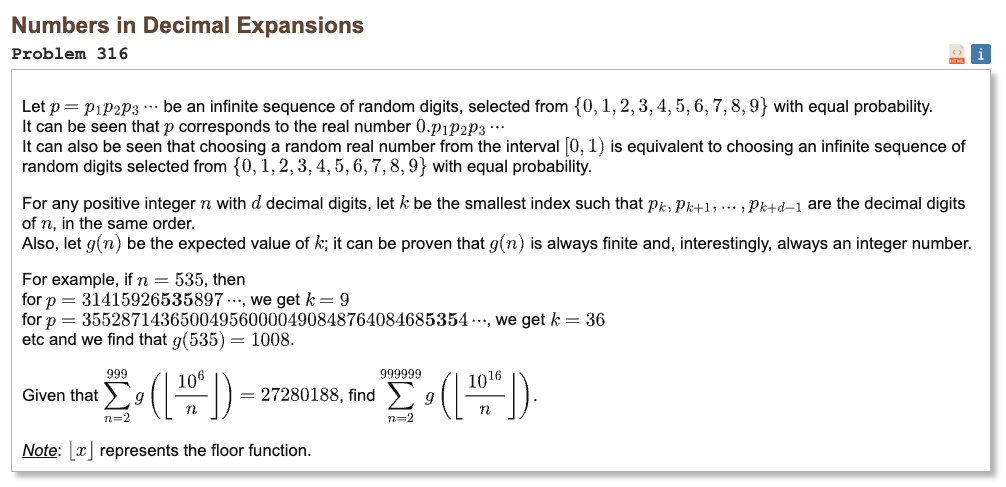

## Initial approach

* use the waiting-time rule for a fixed digit pattern
* the expected value depends only on how the number overlaps with itself
* every full pattern contributes its main waiting time
* every prefix that is also a suffix adds an extra waiting contribution
* for each value, convert it to a string and find its border lengths
* compute this for all required floor values
* sum all expected values directly because there are only about one million terms

In [1]:
def border_lengths(s):
    pi = [0] * len(s)

    for i in range(1, len(s)):
        j = pi[i - 1]

        while j > 0 and s[i] != s[j]:
            j = pi[j - 1]

        if s[i] == s[j]:
            j += 1

        pi[i] = j

    lengths = [len(s)]
    k = pi[-1]

    while k > 0:
        lengths.append(k)
        k = pi[k - 1]

    return lengths

def g(n):
    s = str(n)
    total = 0

    for length in border_lengths(s):
        total += 10 ** length

    return total

def solve():
    total = 0
    limit = 10 ** 16

    for n in range(2, 1_000_000):
        total += g(limit // n)

    return total

assert g(535) == 1010

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 542934735762028820
CPU times: user 896 ms, sys: 6.35 ms, total: 902 ms
Wall time: 902 ms
